<a href="https://colab.research.google.com/github/itharavenikarthik/Machine-learning/blob/main/2403A52200_ML_Lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#pearson corelation heatmap.

##pearson corelation heatmap(pre processing) to improve model accuracy.

In [ ]:
import pandas as pd
df = pd.read_csv("/content/boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


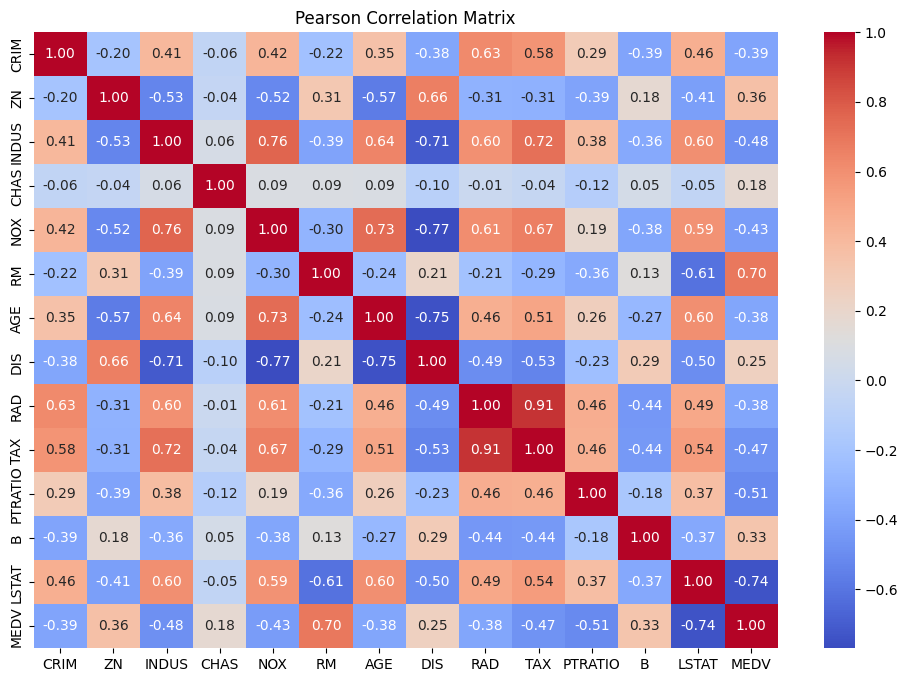

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix=df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Pearson Correlation Matrix")
plt.show()

In [ ]:
corr_with_target=corr_matrix['MEDV'].sort_values(ascending=False)
print(corr_with_target)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


In [ ]:
high_corr_features=corr_with_target[abs(corr_with_target)>0.5]
high_corr_features



,MEDV
MEDV,1.000000
RM,0.695360
PTRATIO,-0.507787
LSTAT,-0.737663


In [ ]:
from numpy._core.defchararray import lower
def remove_outliers(df,columns):
  for col in columns:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df=df[(df[col]>=lower)&(df[col]<=upper)]
  return df


In [ ]:
important_cols=high_corr_features.index.tolist()
important_cols.remove('MEDV')
df_clean=remove_outliers(df,important_cols)

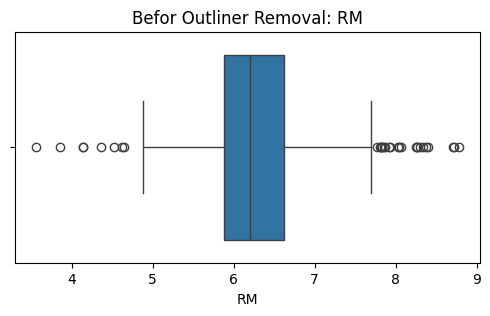

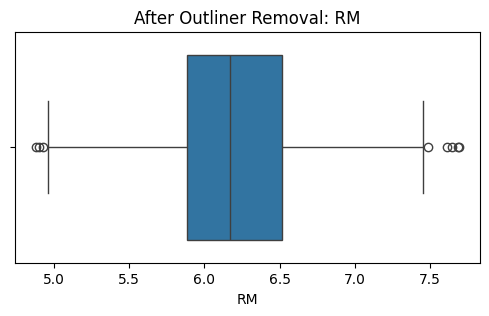

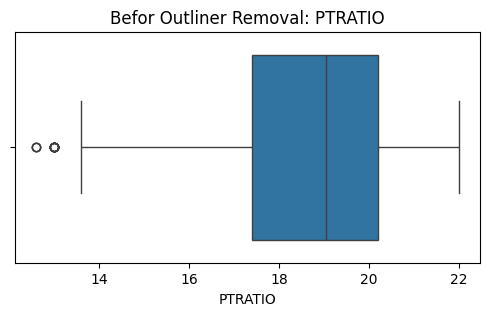

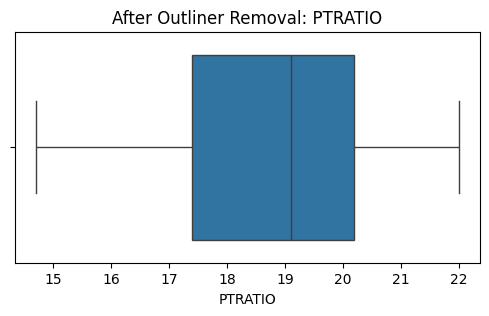

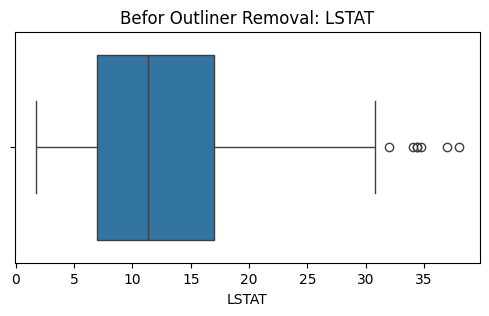

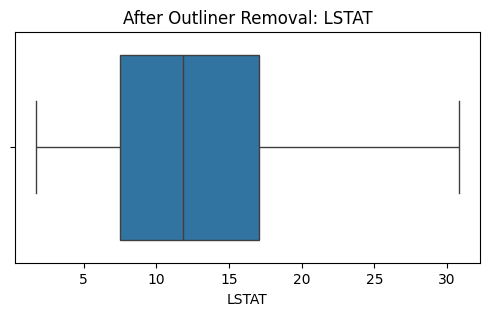

In [ ]:
for col in important_cols:
  plt.figure(figsize=(6,3))
  sns.boxplot(x=df[col])
  plt.title(f"Befor Outliner Removal: {col}")
  plt.show()
  plt.figure(figsize=(6,3))
  sns.boxplot(x=df_clean[col])
  plt.title(f"After Outliner Removal: {col}")
  plt.show()

In [ ]:
x=df_clean.drop('MEDV',axis=1)
y=df_clean['MEDV']
x

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48
